# MDA + RBF (Aveiro Waves)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from bluemath_tk.datamining.mda import MDA
from bluemath_tk.interpolation.rbf import RBF
from utils.plotting import plot_variable_combinations

## Load Dataset

In [2]:
data = (
    xr.open_dataset(
        "/workspaces/BlueMath/climate_services/probabilistic/MUSCLE_Aveiro/inputs/waves_EF_daily.nc"
    )
    .rename({"swh": "Hs", "pp1d": "Tp", "mwd": "Dir"})
    .to_dataframe()
    .reset_index()
    .drop(columns=["latitude", "longitude", "time", "EF"])
)
data

,Hs,Tp,Dir
0,4.223473,12.484236,207.872380
1,3.823032,13.838945,245.494210
2,3.315165,10.994494,247.123025
3,3.660082,12.061756,268.459450
4,2.485282,11.662056,274.258270
...,...,...,...
30676,2.363185,9.037355,226.681807
30677,3.099594,12.230338,260.125392
30678,2.727585,12.531833,290.349343
30679,2.012759,11.215513,295.371523


In [3]:
num_centers = 100
dir_vars = ["Dir"]

mda = MDA(num_centers=num_centers)
nearest_centroids_idxs, nearest_centroids_df = mda.fit_predict(
    data=data,
    directional_variables=dir_vars,
)

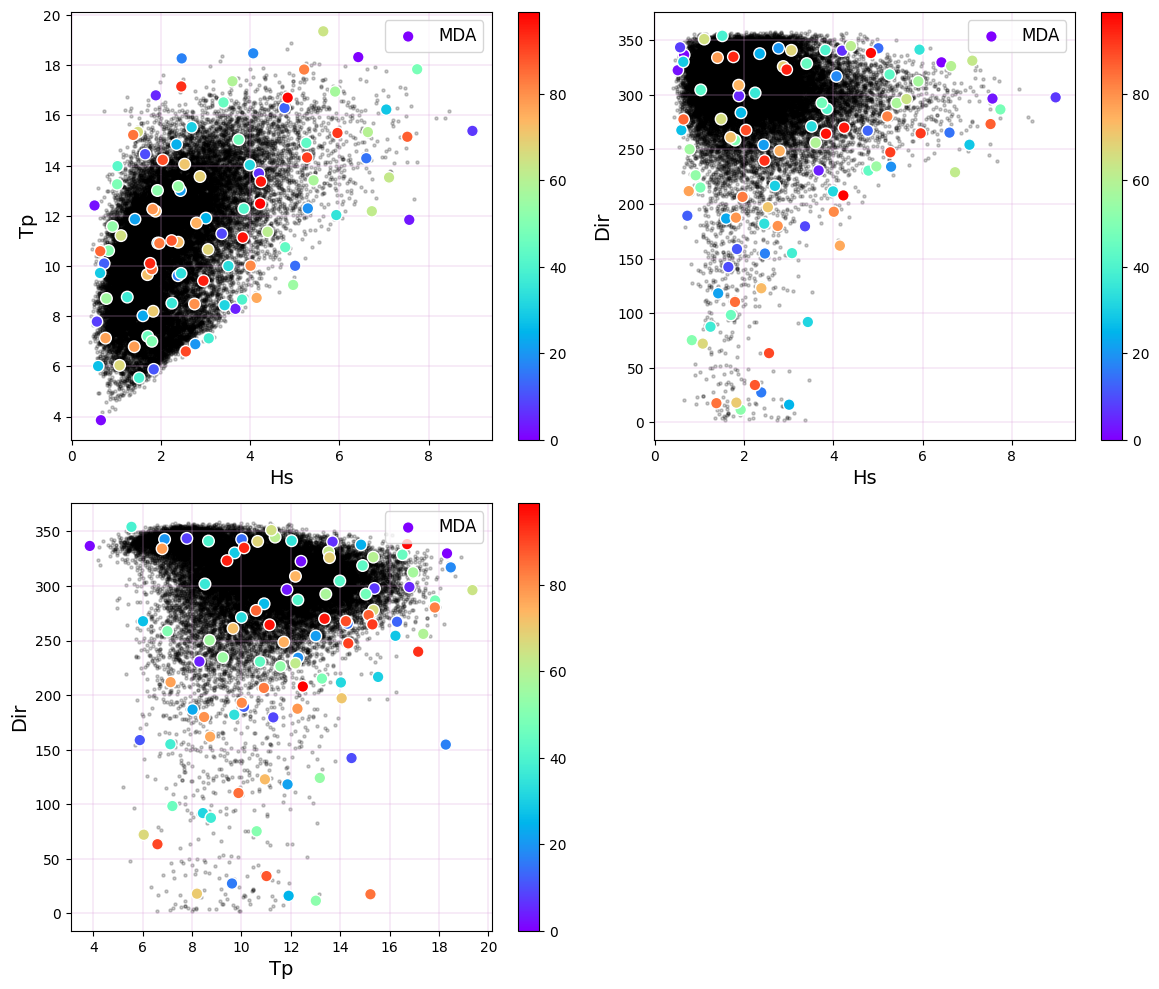

In [4]:
vars = ["Hs", "Tp", "Dir"]  # Lista de variables
sel_mda = mda.centroids[vars]  # Selección de puntos
plot_variable_combinations(mda.data, vars, mda.centroids, labels="MDA")

# MDA + RBF

The energy flux EF, depends on the variables Hs and Tp, and can be computed follwing: EF = Hs**2 * Tp

In [5]:
target = pd.DataFrame(
    {
        "EF": mda.centroids.Hs.values**2 * mda.centroids.Tp.values,
    }
)

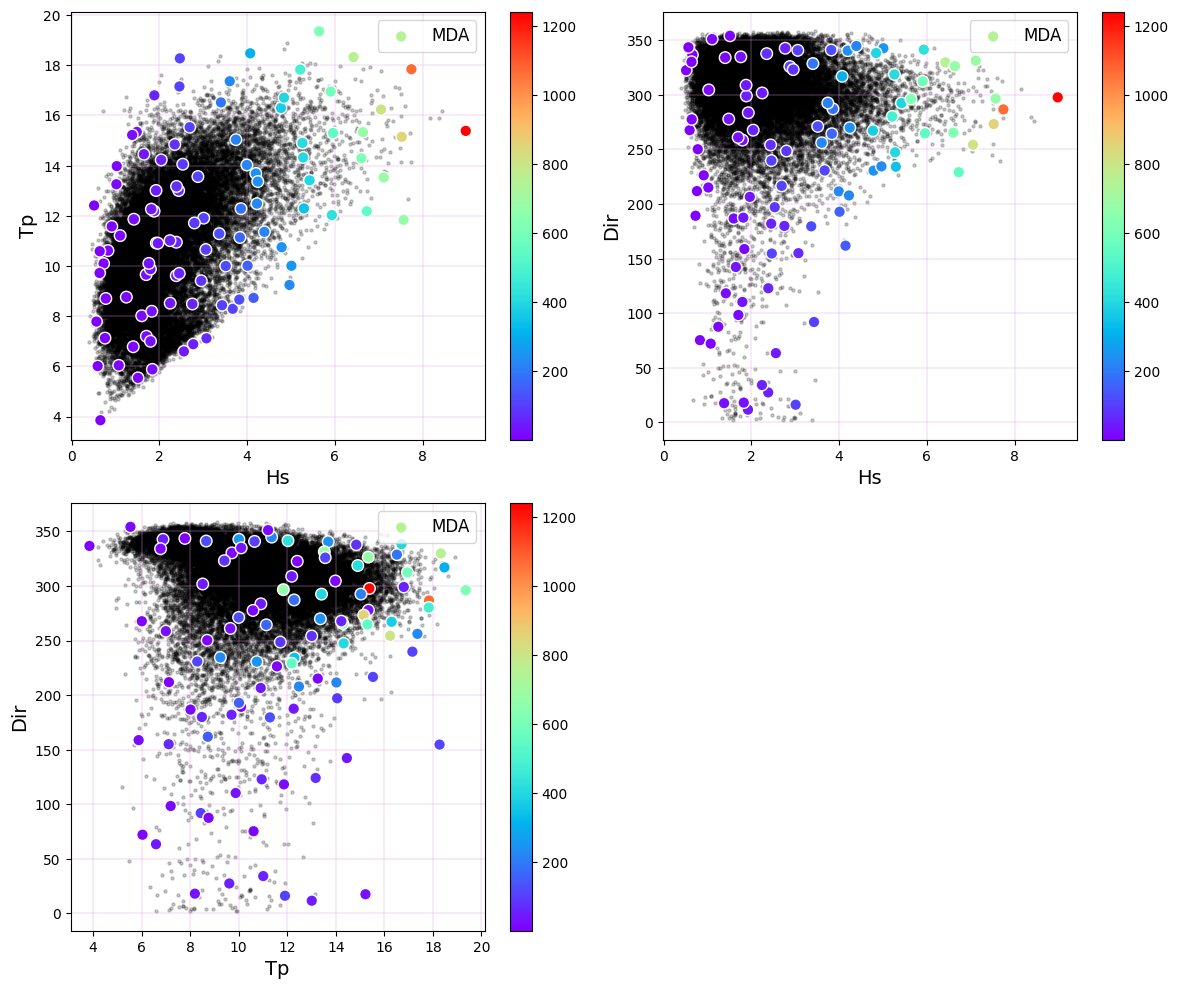

In [6]:
vars = ["Hs", "Tp", "Dir"]  # Lista de variables
sel_mda = mda.centroids[vars]  # Selección de puntos
plot_variable_combinations(
    mda.data, vars, mda.centroids, sel_color=target.EF, labels="MDA"
)

## RBF

In [7]:
dataset = data  # Data to interpolate

subset = mda.centroids  # Parameters to fit RBF
target = target  # Response to fit RBF

subset_directional_variables = ["Dir"]
target_directional_variables = []

In [8]:
rbf = RBF()

predictions = rbf.fit_predict(
    subset_data=subset,
    subset_directional_variables=subset_directional_variables,
    target_data=target,
    target_directional_variables=target_directional_variables,
    normalize_target_data=True,
    dataset=dataset,
    num_workers=4,
    iteratively_update_sigma=True,
)
print(predictions.head())

           EF
0  222.475844
1  203.466617
2  119.397022
3  160.872201
4   69.255357


In [9]:
predictions

,EF
0,222.475844
1,203.466617
2,119.397022
3,160.872201
4,69.255357
...,...
30676,48.585909
30677,116.351480
30678,91.112277
30679,46.705347


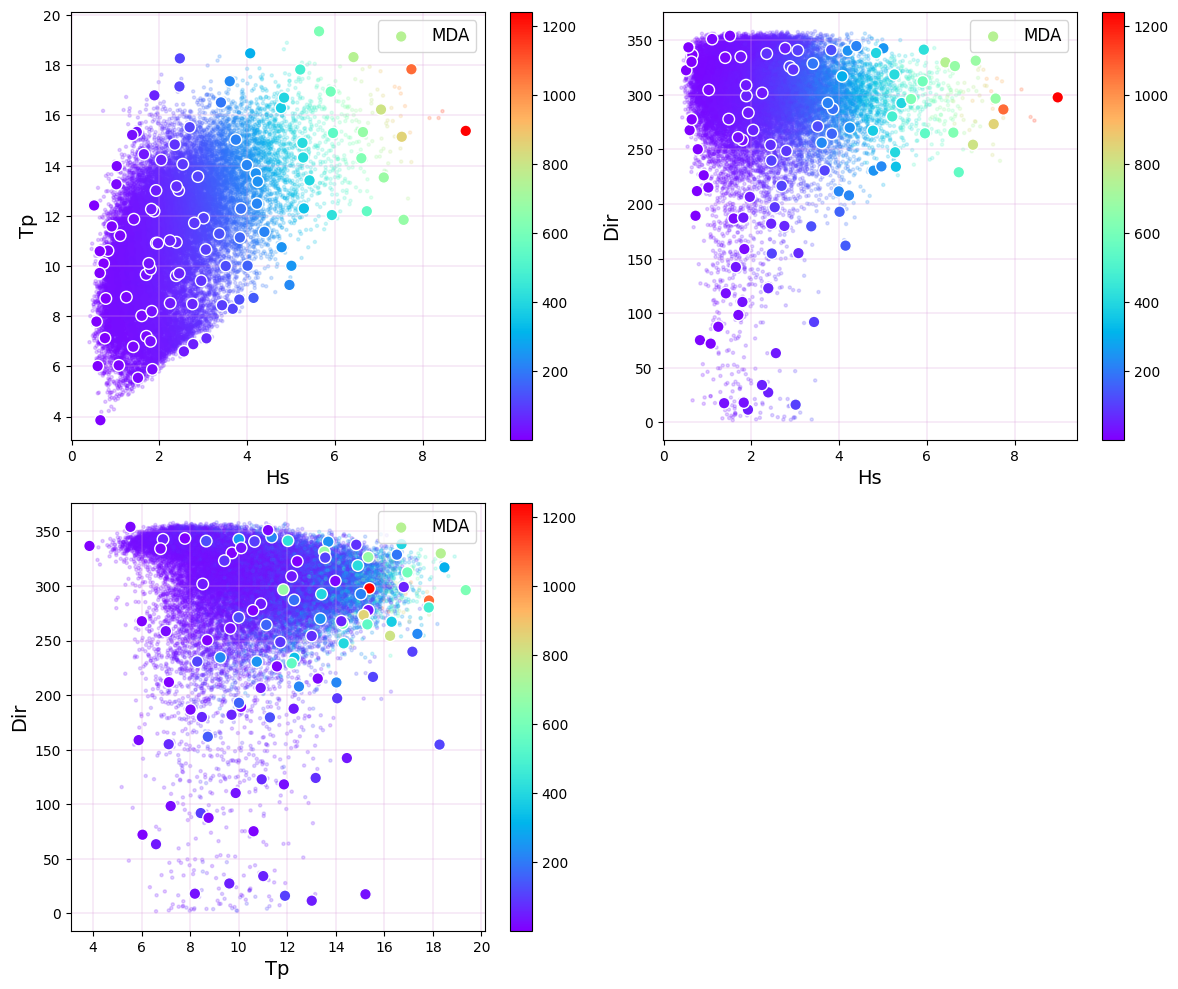

In [10]:
vars = ["Hs", "Tp", "Dir"]  # Lista de variables
sel_mda = mda.centroids[vars]  # Selección de puntos
plot_variable_combinations(
    mda.data,
    vars,
    mda.centroids,
    data_color=predictions.EF,
    sel_color=target.EF,
    labels="MDA",
)

## 14. Root Mean Square Error

$$\textbf{RMSE =  } sqrt(\frac{\sum(RBF_{model} - Real)^2}{n})$$


In [11]:
RMSE = np.sqrt(np.mean((predictions.EF - (data.Hs**2 * data.Tp)) ** 2))
RMSE

np.float64(2.2772662801860624)

## 15. Optimal number of points

- Select 50 values between 10 and 600

In [12]:
num_centers_explore = np.arange(10, 600, 50)

In [13]:
RMSE = []
rbf = RBF()
rbf.set_logger_name(name="RBF-file", level="WARN", console=False)

for d in num_centers_explore:
    # MDA
    dir_vars = ["Dir"]

    mda = MDA(num_centers=d)
    nearest_centroids_idxs, nearest_centroids_df = mda.fit_predict(
        data=data,
        directional_variables=dir_vars,
    )

    target = pd.DataFrame(
        {
            "EF": mda.centroids.Hs.values**2 * mda.centroids.Tp.values,
        }
    )

    # RBF

    subset = mda.centroids  # Parameters to fit RBF
    target = target  # Response to fit RBF

    predictions = rbf.fit_predict(
        subset_data=subset,
        subset_directional_variables=subset_directional_variables,
        target_data=target,
        target_directional_variables=target_directional_variables,
        normalize_target_data=True,
        dataset=dataset,
        num_workers=4,
        iteratively_update_sigma=True,
    )

    RMSE.append(np.sqrt(np.mean((predictions.EF - (data.Hs**2 * data.Tp)) ** 2)))

Text(0, 0.5, 'RMSE')

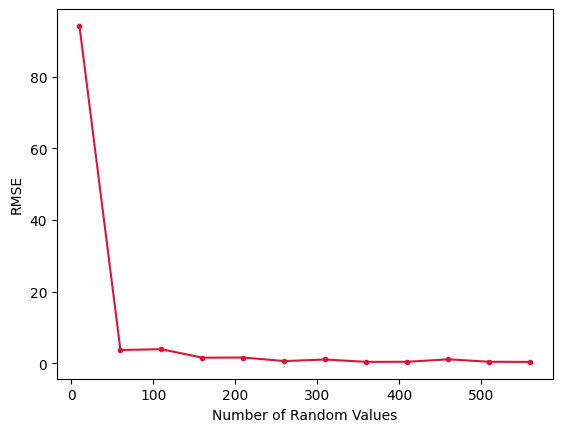

In [14]:
plt.plot(num_centers_explore, RMSE, ".-", color="crimson")
plt.xlabel("Number of Random Values")
plt.ylabel("RMSE")